In [61]:
import pandas as pd
data = pd.read_csv("./NMES1988.csv")

In [62]:
print(data['visits'].describe())

count    4406.000000
mean        5.774399
std         6.759225
min         0.000000
25%         1.000000
50%         4.000000
75%         8.000000
max        89.000000
Name: visits, dtype: float64


In [63]:
from scipy.stats import kurtosis, skew
kurtosis_value = kurtosis(data['visits'])
skewness_value = skew(data['visits'])
print("Эксцесс:", kurtosis_value)
print("Асимметрия:", skewness_value)

Эксцесс: 20.2064540726094
Асимметрия: 3.338174405694495


In [64]:
from scipy.stats import shapiro
stat, p_value = shapiro(data['visits'])
print("p-value:", p_value)

p-value: 5.712918098127624e-65


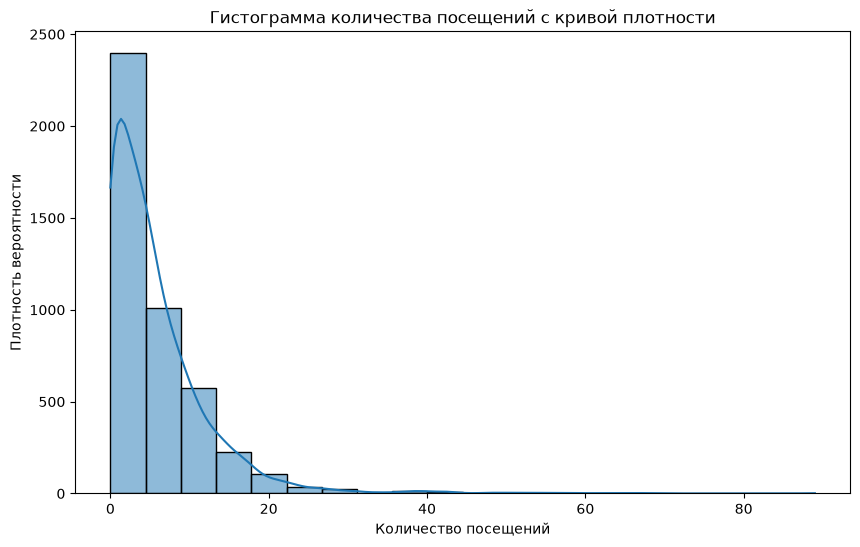

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data['visits'], kde=True, bins=20)
plt.xlabel("Количество посещений")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма количества посещений с кривой плотности")
plt.show()

7 Рассчитайте количество мужчин и женщин в выборке.

In [66]:
gender_counts = data['gender'].value_counts()
print(gender_counts)

gender
female    2628
male      1778
Name: count, dtype: int64


8 Рассчитайте среднее значение (mean) и стандартную ошибку среднего для показателя visits.
SE= sd(x)/ sqrt (length(x)), 
т.е., стандартная ошибка среднего есть стандартное отклонение (sd), деленное на корень квадратный из количества элементов в выборке.

In [67]:
print(data['visits'].mean())
print(data['visits'].std())
SE = data['visits'].std() / (len(data['visits']) ** 0.5)
print(SE)

5.774398547435315
6.759224615447939
0.10182973939055334


9 Рассчитайте медианное значение и квартили для показателя visits (summary).

In [68]:
print(data['visits'].describe())

count    4406.000000
mean        5.774399
std         6.759225
min         0.000000
25%         1.000000
50%         4.000000
75%         8.000000
max        89.000000
Name: visits, dtype: float64


10 Рассчитайте медианные значения и квартили для количественных данных отдельно для мужчин и женщин.

In [69]:
print(data.groupby('gender')['visits'].describe())

         count      mean       std  min  25%  50%  75%   max
gender                                                      
female  2628.0  6.014079  6.589852  0.0  2.0  4.0  8.0  61.0
male    1778.0  5.420135  6.988903  0.0  1.0  4.0  7.0  89.0


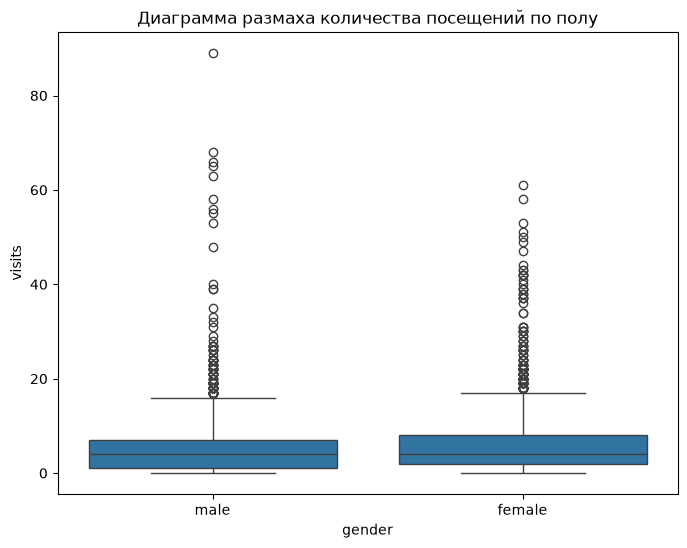

In [70]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='visits', data=data)
plt.title("Диаграмма размаха количества посещений по полу")
plt.show()

In [71]:
median_by_gender_health = data.groupby(['gender', 'health'])['visits'].median()
print(median_by_gender_health)

gender  health   
female  average      4.0
        excellent    2.0
        poor         7.0
male    average      3.0
        excellent    2.0
        poor         6.0
Name: visits, dtype: float64


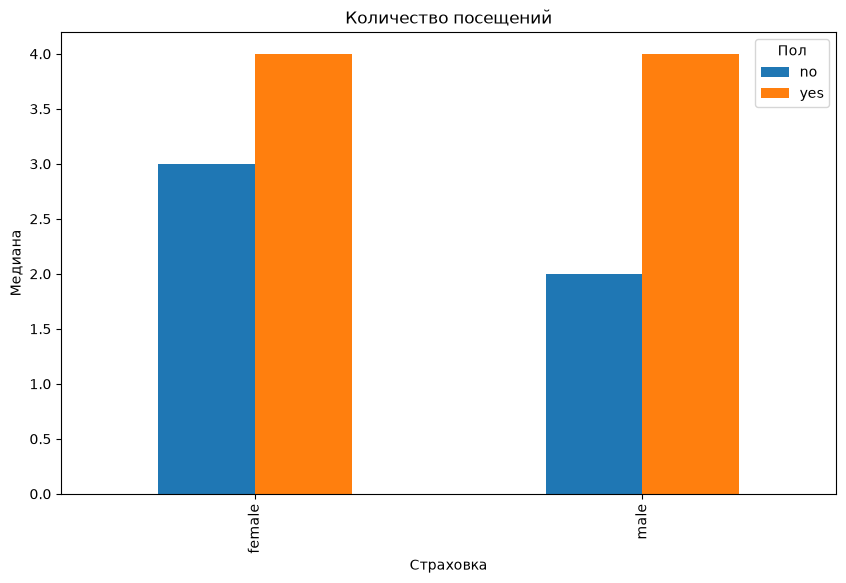

In [72]:
medians = data.groupby(['gender', 'insurance'])['visits'].median().unstack()
medians.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Страховка")
plt.ylabel("Медиана")
plt.title("Количество посещений")
plt.legend(title="Пол")
plt.show()

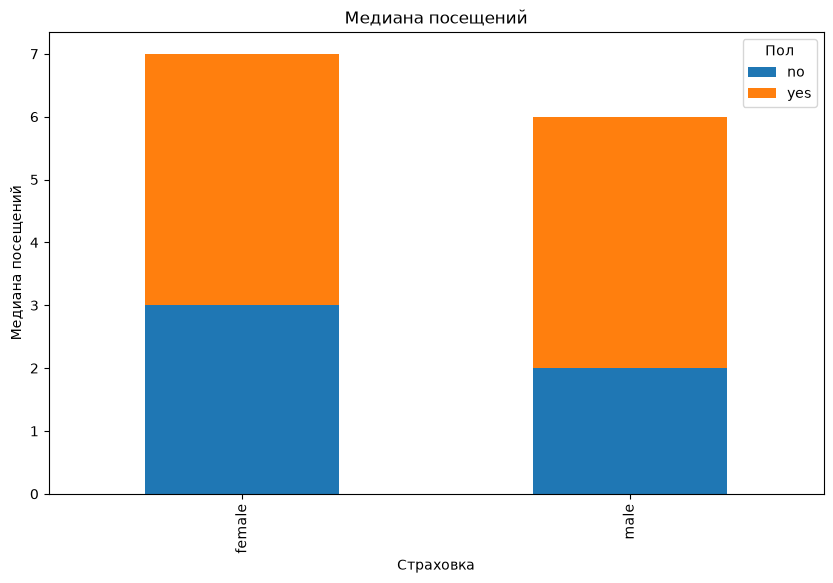

In [73]:
medians.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel("Страховка")
plt.ylabel("Медиана посещений")
plt.title("Медиана посещений")
plt.legend(title="Пол")
plt.show()

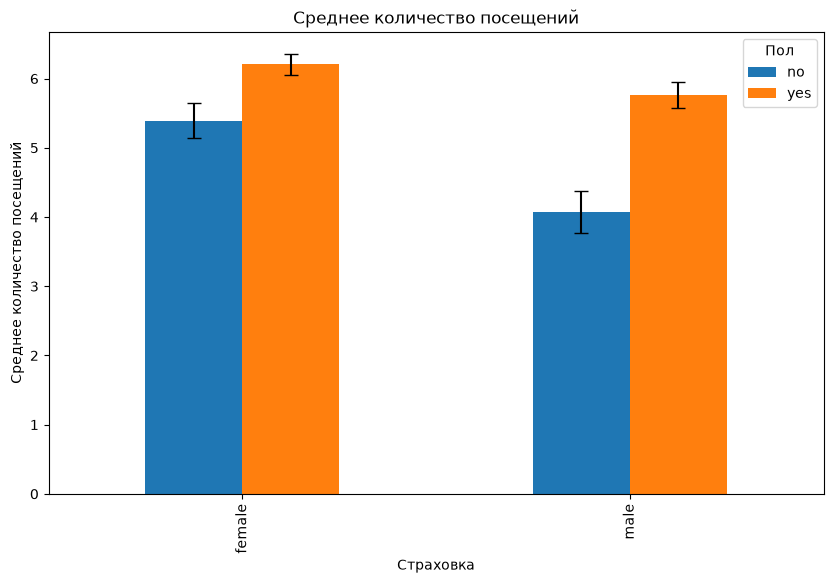

In [74]:
means = data.groupby(['gender', 'insurance'])['visits'].mean().unstack()
se = data.groupby(['gender', 'insurance'])['visits'].sem().unstack()
ax = means.plot(kind='bar', figsize=(10, 6), yerr=se, capsize=5)
plt.xlabel("Страховка")
plt.ylabel("Среднее количество посещений")
plt.title("Среднее количество посещений")
plt.legend(title="Пол")
plt.show()

In [75]:
from scipy import stats
import numpy as np
# Расчет 95% доверительного интервала для среднего
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)  # стандартная ошибка среднего
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h
# Для переменной visits
mean_visits, ci_lower, ci_upper = confidence_interval(data['visits'].dropna())
print(f"Среднее: {mean_visits:.2f}")
print(f"95% доверительный интервал: [{ci_lower:.2f}, {ci_upper:.2f}]")

Среднее: 5.77
95% доверительный интервал: [5.57, 5.97]


Text(0, 0.5, 'Количество посещений')

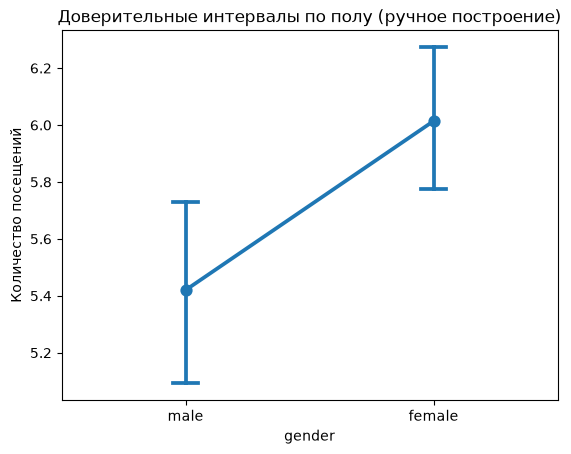

In [76]:
sns.pointplot(x='gender', y='visits', data=data, capsize=0.1)
plt.title('Доверительные интервалы по полу (seaborn)')
plt.ylabel('Количество посещений')
plt.title('Доверительные интервалы по полу (ручное построение)')
plt.ylabel('Количество посещений')

16 Рассчитайте медианное значение и доверительный интервал возраста по категориям показателя married по всей выборке и отдельно для мужчин и женщин. Визуализируйте результат с помощью функции pd.DataFrame.plot(kind='bar') и sns.pointplot()
Проанализируйте результаты.

In [77]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)  # стандартная ошибка среднего
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h
# Для переменной visits
mean_visits, ci_lower, ci_upper = confidence_interval(data['visits'].dropna())
print(f"Среднее: {mean_visits:.2f}")
print(f"95% доверительный интервал: [{ci_lower:.2f}, {ci_upper:.2f}]")



Среднее: 5.77
95% доверительный интервал: [5.57, 5.97]


По всей выборке

In [78]:
results_all = []

for married, group in data.groupby('married'):
    median, lower, upper = confidence_interval(group['age'])
    
    results_all.append({'married': married,'median': median,'lower': lower,'upper': upper})

results_all = pd.DataFrame(results_all)

print(results_all)

  married    median     lower     upper
0      no  7.576450  7.546061  7.606839
1     yes  7.257731  7.236219  7.279243


Для мужчин

In [79]:
results_men = []

for married, group in data[data['gender'] == 'male'].groupby('married'):
    median, lower, upper = confidence_interval(group['age'])
    
    results_men.append({'married': married,'median': median,'lower': lower,'upper': upper})

results_men = pd.DataFrame(results_men)

print(results_men)

  married    median     lower     upper
0      no  7.520256  7.450776  7.589737
1     yes  7.313184  7.282720  7.343649


Для женщин

In [80]:
results_women = []

for married, group in data[data['gender'] == 'female'].groupby('married'):
    median, lower, upper = confidence_interval(group['age'])
    results_women.append({'married': married,'median': median,'lower': lower,'upper': upper})

results_women = pd.DataFrame(results_women)

print(results_women)

  married    median     lower     upper
0      no  7.590062  7.556268  7.623856
1     yes  7.182122  7.153389  7.210855


График

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def plot_median_ci(results):
    yerr = np.array([results['median'] - results['lower'], results['upper'] - results['median']])
    
    results.set_index('married')['median'].plot(kind='bar', yerr=yerr)
    
    plt.show()

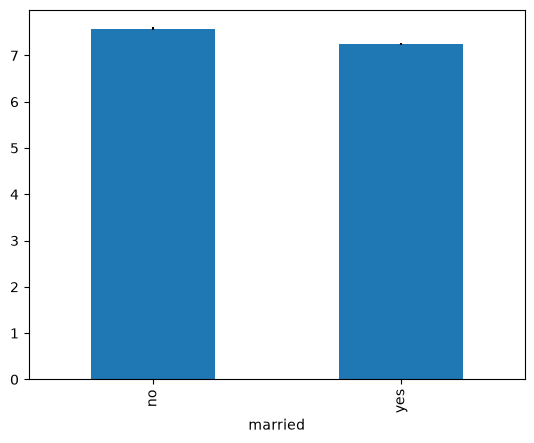

In [82]:
plot_median_ci(results_all)

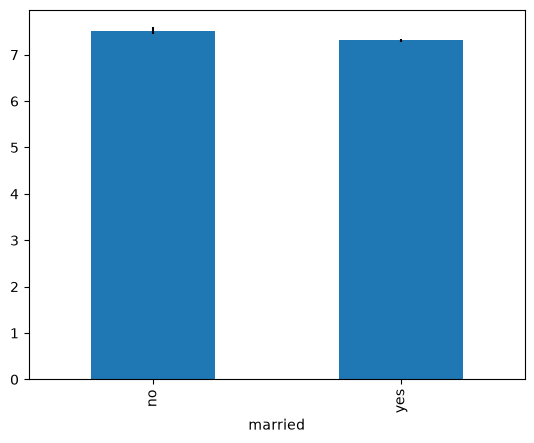

In [83]:
plot_median_ci(results_men)

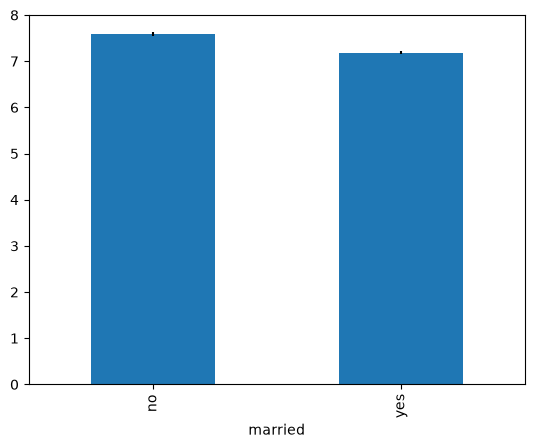

In [84]:
plot_median_ci(results_women)

для всей выборки

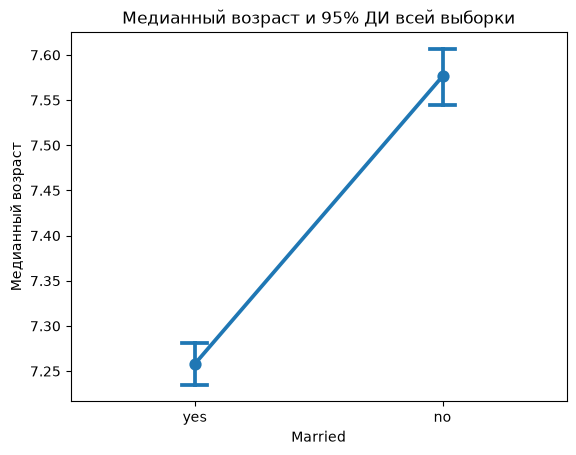

In [85]:
sns.pointplot(x='married', y='age', data=data, capsize=0.1)

plt.xlabel('Married')
plt.ylabel('Медианный возраст')
plt.title('Медианный возраст и 95% ДИ всей выборки')
plt.show()

для мужчин

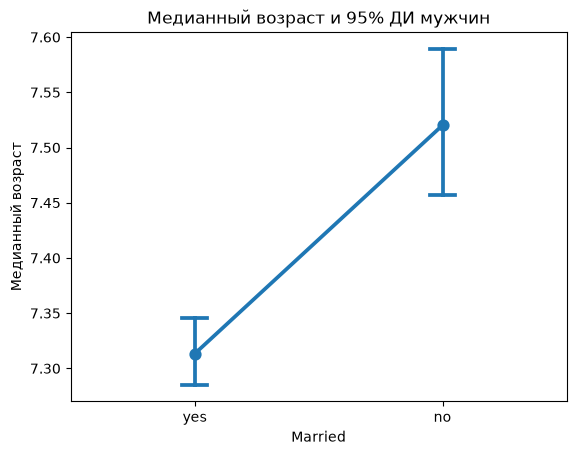

In [86]:
sns.pointplot(x='married', y='age', data=data[data['gender'] == 'male'], capsize=0.1)

plt.xlabel('Married')
plt.ylabel('Медианный возраст')
plt.title('Медианный возраст и 95% ДИ мужчин')
plt.show()

для женщин

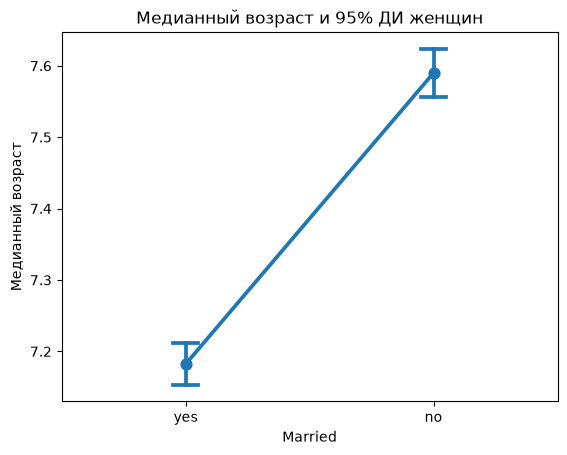

In [87]:
sns.pointplot(x='married', y='age', data=data[data['gender'] == 'female'], capsize=0.1)

plt.xlabel('Married')
plt.ylabel('Медианный возраст')
plt.title('Медианный возраст и 95% ДИ женщин')
plt.show()

Анализ:
Люди в браке младше тех, кто не в браке.
Медианный возраст у мужчин не вбраке, что в доверительном интервале, имеет больший разброс значений - чуть менее определен, чем у женщин.